In [1]:
import re
from collections import Counter
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import emoji
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ML & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras import backend as K

# Ensure reproducibility 
import os
import random

def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

SEED = 42
set_seed(SEED)

2025-06-19 16:41:56.502343: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load the data
amazon_df = pd.read_csv('amazon_cells_labelled.txt', sep='\t', header=None, names=["review", "rating"])
imdb_df = pd.read_csv('imdb_labelled.txt', sep='\t', header=None, names=["review", "rating"])
yelp_df = pd.read_csv('yelp_labelled.txt', sep='\t', header=None, names=["review", "rating"])

# Concatenate the datasets into one dataset
combined_df = pd.concat([amazon_df, imdb_df, yelp_df], ignore_index=True)

# Save combined dataset to CSV
combined_df.to_csv('d213_task2_combined.csv')

In [3]:
# Preview the concatenated (combined) data set
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  2748 non-null   object
 1   rating  2748 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 43.1+ KB


In [4]:
# Ensure each entry includes a text review + sentiment (rating) label 
combined_df.head()

,review,rating
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [5]:
# Check for data imbalance
combined_df['rating'].value_counts()

1    1386
0    1362
Name: rating, dtype: int64

### Presence of Unsual Characters

In [6]:
# Combine all text data into a single string for character-level analysis
all_text = " ".join(combined_df["review"].astype(str))

# Identify unusual (non-ASCII) characters — including potential emojis
unusual_chars = sorted(set(re.findall(r'[^\x00-\x7F]', all_text)))

# Function to detect if any emoji is present in a given text
def contains_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in text)

# Apply emoji check across reviews
combined_df["has_emoji"] = combined_df["review"].astype(str).apply(contains_emoji)

# Count how many entries contain emojis
emoji_counts = combined_df["has_emoji"].value_counts()

# Display results
print("Unusual Characters:", unusual_chars)
print("\nEmoji Presence Count:\n", emoji_counts)

Unusual Characters: ['\x85', '\x96', '\x97', 'å', 'é', 'ê']

Emoji Presence Count:
 False    2748
Name: has_emoji, dtype: int64


### Normalization

In [7]:
# Normalize the text
def clean_text(text):
    text = text.lower() # uniformally convert text to lowercase
    text = re.sub(r"[^a-z0-9\s]", "", text) # strip punctuation, symbols & non-alphanumeric characters
    return text

combined_df["cleaned_review"] = combined_df['review'].astype(str).apply(clean_text)
ratings = combined_df['rating'].astype(int)

### Tokenization

In [8]:
# Tokenize and convert to sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(combined_df["cleaned_review"])
sequences = tokenizer.texts_to_sequences(combined_df["cleaned_review"])

### Vocabulary Size

In [9]:
# Vocab size
vocab_size = len(tokenizer.word_index)

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 5402


### Proposed Word Embedding Length

In [10]:
# Propose a word embedding length
embedding_dim = int(round(vocab_size ** 0.25))  # 4th root of vocab size 

print("Proposed Word Embedding Length:", embedding_dim)

Proposed Word Embedding Length: 9


### Word Count & Frequency

In [11]:
# Word frequencies 
top_words = pd.DataFrame(tokenizer.word_counts.items(), columns=["word", "count"]).sort_values(by="count", ascending=False)

# Top 30 (most frequent) words
top_words[:30] 

,word,count
12,the,1940
71,and,1129
15,i,887
18,a,886
2,is,753
7,to,666
9,it,665
63,this,639
54,of,621
76,was,569


In [12]:
# Bottom 10 words (previewing to double-check the last index matches vocab size)
bottom_words = top_words.tail(10)
print(bottom_words)

               word  count
3182       shooting      1
3184      completed      1
1444        linksys      1
3186  personalities      1
3188         twists      1
3189          occur      1
3190     irritating      1
3191  indescribably      1
3192        idiotic      1
5401        drawing      1


### Maximum Sequence Length

In [13]:
# Token counts
combined_df['token_count'] = [len(seq) for seq in sequences]

# Calculate summary statistics
max_seq_length = combined_df["token_count"].max() # max
mean_seq_length = combined_df["token_count"].mean() # mean
std_seq_length = combined_df["token_count"].std() # std
suggested_max_seq_length = round(mean_seq_length + 2 * std_seq_length) # suggested max using statistical rule of thumb

print(f"Max Sequence Length: {max_seq_length}")
print(f"Mean Sequence Length: {mean_seq_length:.2f}")
print(f"Std Dev Sequence Length: {std_seq_length:.2f}")
print(f"Suggested Maximum Sequence Length (mean + 2 * std): {suggested_max_seq_length}")

Max Sequence Length: 1384
Mean Sequence Length: 12.95
Std Dev Sequence Length: 35.68
Suggested Maximum Sequence Length (mean + 2 * std): 84


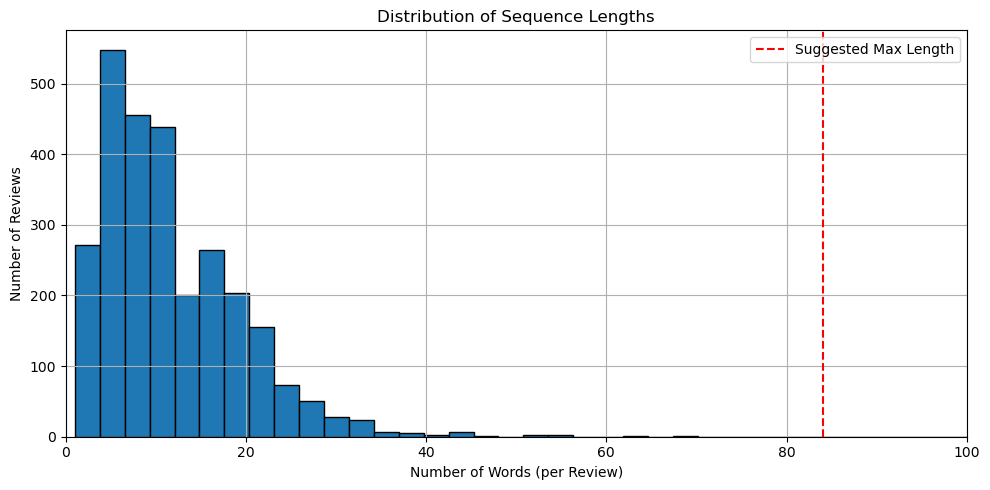

In [14]:
# Visualize distribution of sequence lengths 
plt.figure(figsize=(10, 5))
plt.hist(combined_df['token_count'], bins=500, edgecolor='black')
plt.axvline(suggested_max_seq_length, color='red', linestyle='dashed', linewidth=1.5, label='Suggested Max Length')
plt.xlabel('Number of Words (per Review)')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Sequence Lengths')
plt.legend(loc='upper right') 
plt.xlim(0, 100)  
plt.grid(True)
plt.tight_layout()
plt.show()

### Padding

In [15]:
# Pad vocab size
vocab_size = vocab_size + 1  

# Pad sequences to uniform length
max_sequence_length = suggested_max_seq_length # proposed max sequence length
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

In [16]:
# Original review
print("Original review:\n", combined_df['review'][0])

# Cleaned review
print("Cleaned review:\n", combined_df['cleaned_review'][0])

# Tokenized review
print("Tokenized:\n", sequences[0])

# Padded Sequence Example
print("Padded Sequence:\n", padded_sequences[0])

Original review:
 So there is no way for me to plug it in here in the US unless I go by a converter.
Cleaned review:
 so there is no way for me to plug it in here in the us unless i go by a converter
Tokenized:
 [27, 49, 5, 59, 118, 12, 73, 6, 367, 7, 11, 67, 11, 1, 183, 638, 3, 77, 62, 4, 2209]
Padded Sequence:
 [  27   49    5   59  118   12   73    6  367    7   11   67   11    1
  183  638    3   77   62    4 2209    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0]


### Training, Validation, Test Split

In [17]:
# Prepare labels 
X = padded_sequences
y = np.array(ratings)

# Split into training+validation and test sets (70/30)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED, shuffle=True)

# Split training+validation into training and validation (50/50)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED, shuffle=True)


In [18]:
# Save to CSV
pd.DataFrame(X_train).assign(rating=y_train).to_csv("d213_task2_train_data.csv", index=False)
pd.DataFrame(X_val).assign(rating=y_val).to_csv("d213_task2_validation_data.csv", index=False)
pd.DataFrame(X_test).assign(rating=y_test).to_csv("d213_task2_test_data.csv", index=False)

### Load GloVe Embeddings

In [19]:
embedding_dim = 100 # DO NOT CHANGE THIS VALUE (see report)

# Load GloVe (helps give the model pre-learned word intuition)
embedding_index = {}
with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coeffs

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

### Build the Model (Drop-In GloVe-Powered LSTM Model)

In [20]:
# Ensure clean rebuild
K.clear_session()

# Build the LSTM model 
model = Sequential()
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    input_length=max_sequence_length,  
                    trainable=False)) 
model.add(Bidirectional(LSTM(128))) 
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.build(input_shape=(None, max_sequence_length))
model.summary()

/Users/hannahbergman/anaconda3/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 84, 100)        │       540,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 775,053 (2.96 MB)

 Trainable params: 234,753 (917.00 KB)

 Non-trainable params: 540,300 (2.06 MB)

### Train the Model

In [21]:
# Early stopping (prevents overfitting and finds optimal epoch) 
early_stop = tf.keras.callbacks.EarlyStopping(patience=3, monitor='val_loss', restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.5650 - loss: 0.6737 - val_accuracy: 0.7403 - val_loss: 0.5684
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7225 - loss: 0.5558 - val_accuracy: 0.7646 - val_loss: 0.5307
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7776 - loss: 0.4939 - val_accuracy: 0.7282 - val_loss: 0.5514
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7809 - loss: 0.4744 - val_accuracy: 0.7524 - val_loss: 0.5378
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.7969 - loss: 0.4493 - val_accuracy: 0.7718 - val_loss: 0.4915
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8269 - loss: 0.4006 - val_accuracy: 0.7913 - val_loss: 0.4667
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.8423 - loss: 0.3666 - val_accuracy: 0.7791 - val_loss: 0.4773
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8508 - loss: 0.3431 - val_accuracy: 0.8010 - v

In [22]:
print(f"Training stopped at epoch: {len(history.history['loss'])}")

Training stopped at epoch: 13


### Evaluate Model Performance

In [23]:
 # Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Training stopped at epoch: {len(history.history['loss'])}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8061 - loss: 0.4511

Test Accuracy: 0.8039
Test Loss: 0.4826
Training stopped at epoch: 13


### Visualize Training History

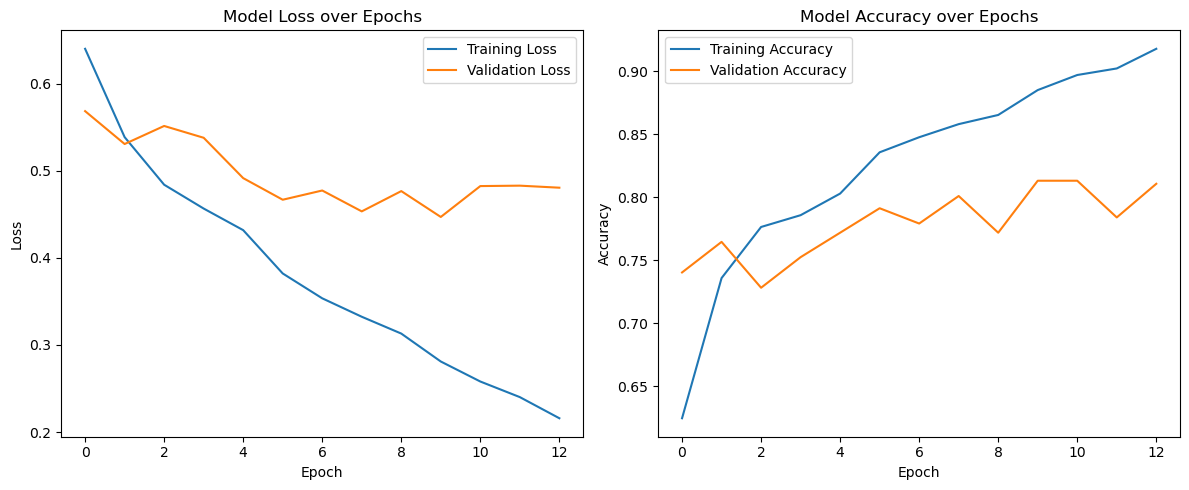

In [24]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
# Quick sanity check to see if model is performing on a few test samples
pred = model.predict(X_test[:5])
print("Predicted probabilities:", pred.flatten())
print("True labels:", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
Predicted probabilities: [0.7618403  0.1613515  0.00531298 0.02003598 0.9400996 ]
True labels: [1 0 0 0 1]
